In [1]:
import os
os.chdir(r'C:\Users\sande\Code\Personal\Python\DataScience\Project_3')

import sys 
sys.path.append('..')

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

from src.data_loader import fetch_all, get_close_prices, TICKERS
from src.features import add_technical_indicators 


# Load all tickers
data= fetch_all()

# Quick summary 
for ticker, df in data.items():
    print(f'{ticker}: {len(df)} trading days | {df.index.min().date()} to {df.index.max().date()}')

AAPL: loaded from cache (1883 rows)
MSFT: loaded from cache (1883 rows)
GOOGL: loaded from cache (1883 rows)
TSLA: loaded from cache (1883 rows)
AMZN: loaded from cache (1883 rows)

All tickers loaded. Date range: 2019-01-01 to 2026-07-01
AAPL: 1883 trading days | 2019-01-02 to 2026-06-30
MSFT: 1883 trading days | 2019-01-02 to 2026-06-30
GOOGL: 1883 trading days | 2019-01-02 to 2026-06-30
TSLA: 1883 trading days | 2019-01-02 to 2026-06-30
AMZN: 1883 trading days | 2019-01-02 to 2026-06-30


AAPL: loaded from cache (1883 rows)
MSFT: loaded from cache (1883 rows)
GOOGL: loaded from cache (1883 rows)
TSLA: loaded from cache (1883 rows)
AMZN: loaded from cache (1883 rows)

All tickers loaded. Date range: 2019-01-01 to 2026-07-01


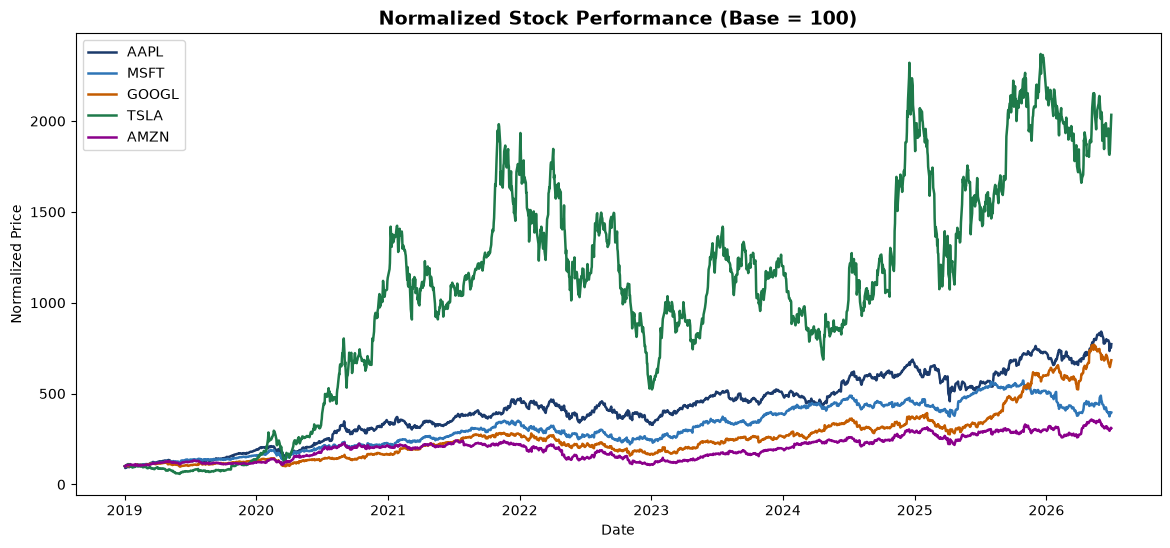

In [2]:
# Normalize all prices to 100 on start date for fair comparison 
close_df = get_close_prices()
normalized = (close_df / close_df.iloc[0]) * 100

plt.figure(figsize=(14,6))
colors = ['#1B3A6B', '#2E75B6', '#C45C00', '#1E7A4A', '#8B008B']
for ticker, color in zip(TICKERS, colors):
    plt.plot(normalized.index, normalized[ticker], label=ticker, 
             color=color, linewidth=1.8)

plt.title('Normalized Stock Performance (Base = 100)', fontsize = 14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.savefig('outputs/figures/01_normalized_prices.png', dpi=150)
plt.show()
    

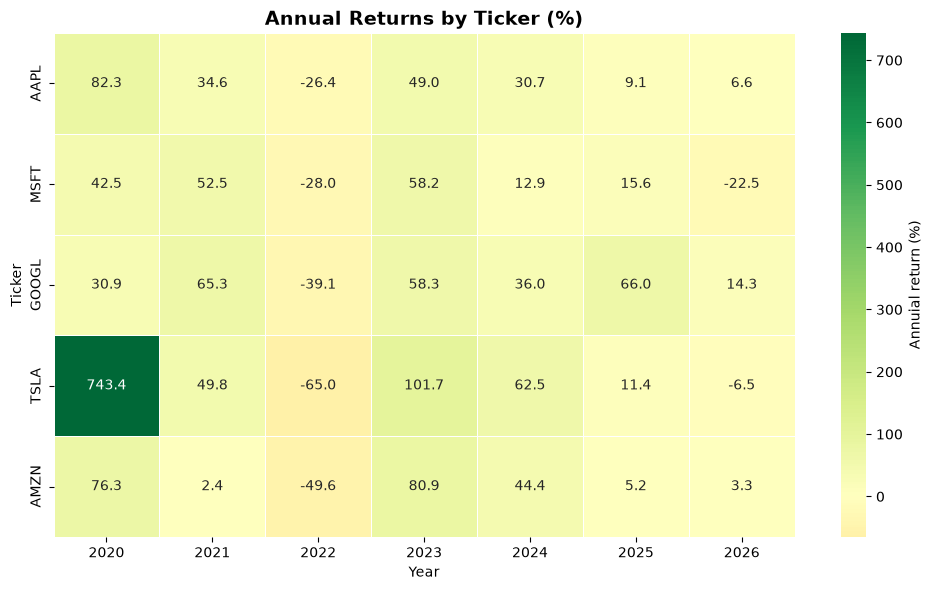

In [3]:
# Calculate annual returns per ticker 
annual_returns = {}
for ticker, df in data.items():
    yearly = df['Close'].resample('YE').last().pct_change() * 100
    annual_returns[ticker] = yearly

returns_df = pd.DataFrame(annual_returns)
returns_df.index = returns_df.index.year
returns_df = returns_df.dropna()

plt.figure(figsize=(10,6))
sns.heatmap(returns_df.T, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'label': 'Annuial return (%)'})
plt.title('Annual Returns by Ticker (%)', fontsize=14, fontweight='bold')
plt.ylabel('Ticker')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('outputs/figures/02_annual_returns.png', dpi=150)
plt.show()
            

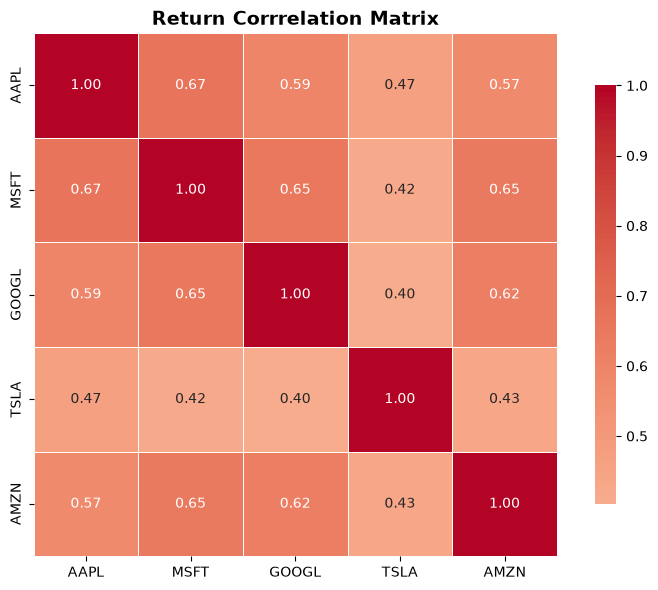

In [4]:
# Correlatikon of daily returns (not prices - prices are not stationary) 
returns = close_df.pct_change().dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot = True, fmt='.2f', cmap='coolwarm',
            center = 0, square =True, linewidths = 0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Return Corrrelation Matrix', fontsize = 14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_correlation_matrix.png', dpi=150)
plt.show()

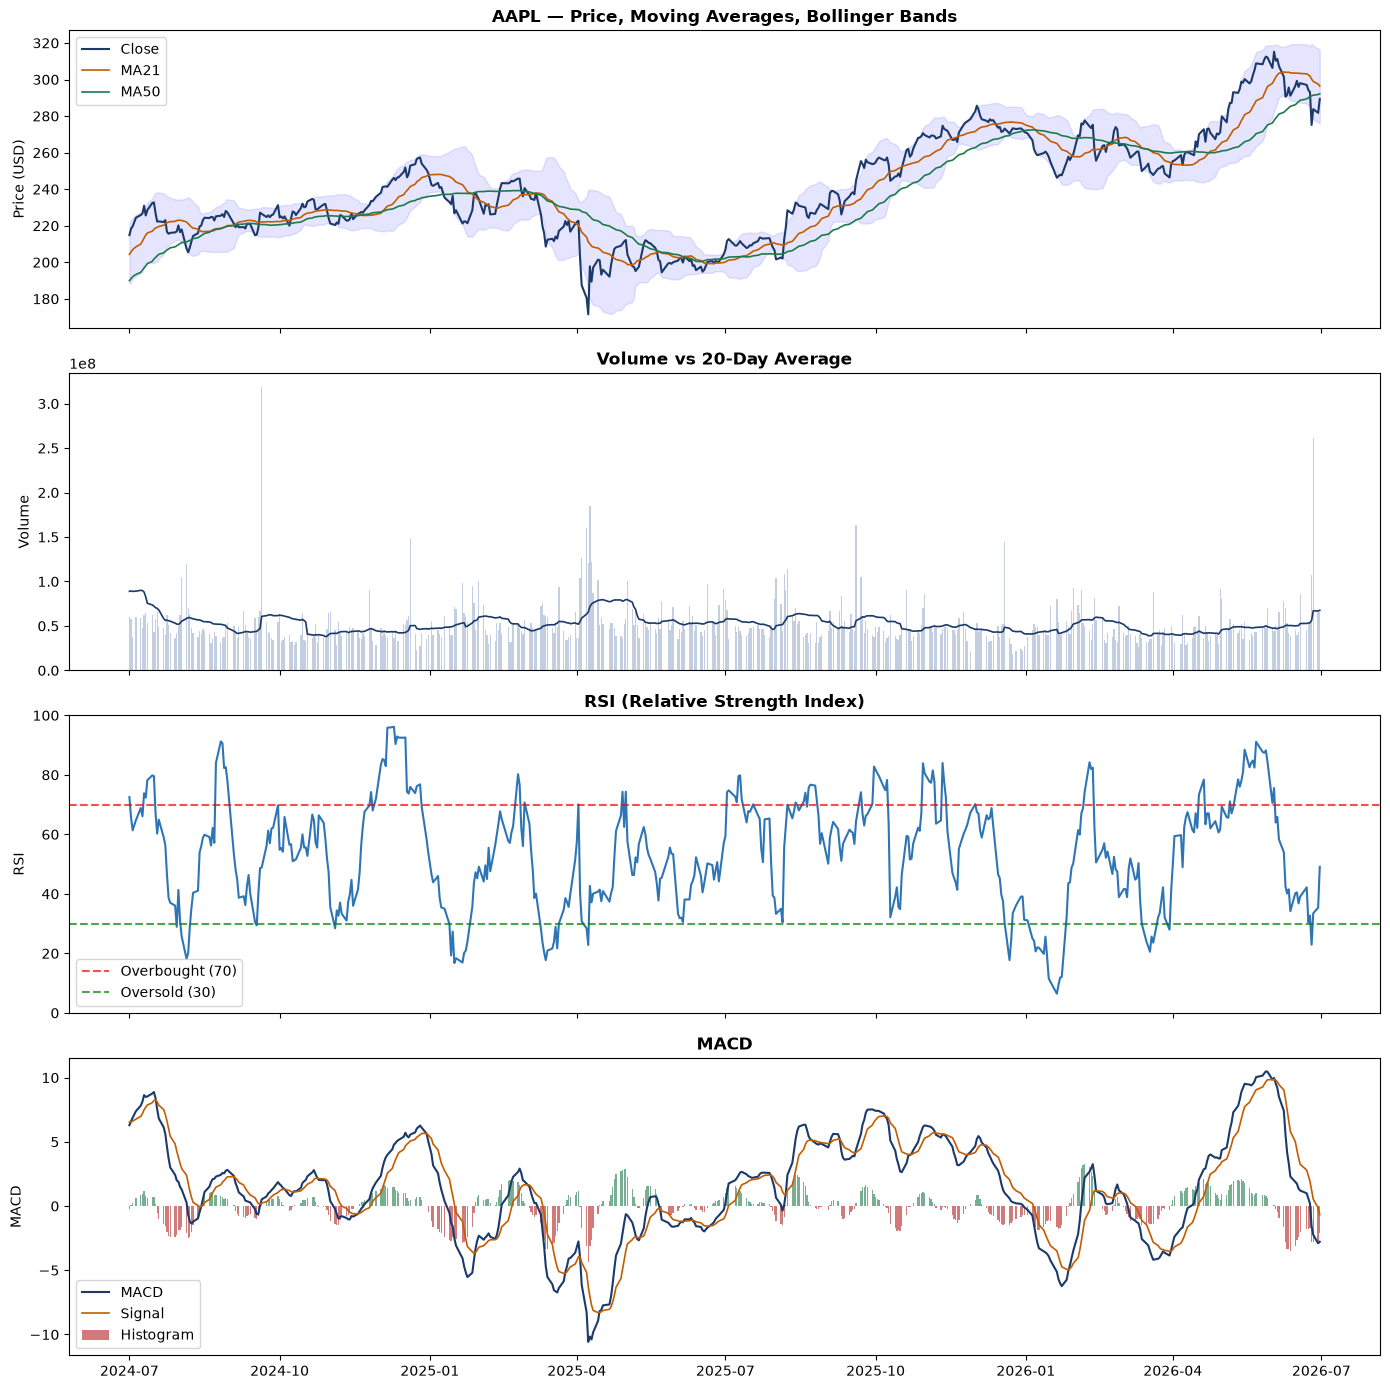

In [5]:
# Show all technical indicators on AAPL for the last 2 years
aapl = add_technical_indicators(data['AAPL'].copy())
aapl_recent = aapl[aapl.index >= aapl.index.max() - pd.DateOffset(years=2)]   # last 2 years
 
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
 
# Panel 1: Price + Bollinger Bands + Moving Averages
axes[0].plot(aapl_recent.index, aapl_recent['Close'], color='#1B3A6B', lw=1.5, label='Close')
axes[0].plot(aapl_recent.index, aapl_recent['MA_21'],  color='#C45C00', lw=1.2, label='MA21')
axes[0].plot(aapl_recent.index, aapl_recent['MA_50'],  color='#1E7A4A', lw=1.2, label='MA50')
axes[0].fill_between(aapl_recent.index, aapl_recent['BB_upper'],
                     aapl_recent['BB_lower'], alpha=0.1, color='blue')
axes[0].set_title('AAPL — Price, Moving Averages, Bollinger Bands', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Price (USD)')
 
# Panel 2: Volume
axes[1].bar(aapl_recent.index, aapl_recent['Volume'], color='#AABBD4', alpha=0.7)
axes[1].plot(aapl_recent.index, aapl_recent['Volume_MA'], color='#1B3A6B', lw=1.2)
axes[1].set_title('Volume vs 20-Day Average', fontweight='bold')
axes[1].set_ylabel('Volume')
 
# Panel 3: RSI
axes[2].plot(aapl_recent.index, aapl_recent['RSI'], color='#2E75B6', lw=1.5)
axes[2].axhline(70, color='red',  linestyle='--', alpha=0.7, label='Overbought (70)')
axes[2].axhline(30, color='green',linestyle='--', alpha=0.7, label='Oversold (30)')
axes[2].set_title('RSI (Relative Strength Index)', fontweight='bold')
axes[2].set_ylabel('RSI')
axes[2].legend()
axes[2].set_ylim(0, 100)
 
# Panel 4: MACD
axes[3].plot(aapl_recent.index, aapl_recent['MACD'],        color='#1B3A6B', lw=1.5, label='MACD')
axes[3].plot(aapl_recent.index, aapl_recent['MACD_signal'], color='#C45C00', lw=1.2, label='Signal')
axes[3].bar(aapl_recent.index, aapl_recent['MACD_hist'],
            color=['#1E7A4A' if v > 0 else '#B22222' for v in aapl_recent['MACD_hist']],
            alpha=0.6, label='Histogram')
axes[3].set_title('MACD', fontweight='bold')
axes[3].set_ylabel('MACD')
axes[3].legend()
 
plt.tight_layout()
plt.savefig('outputs/figures/04_technical_indicators.png', dpi=150)
plt.show()
